In [1]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 20.4 MB/s eta 0:00:00


In [2]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)


Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 122 (delta 46), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 2.43 MiB | 10.52 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Loading pre-computed data from GitHub repository...
Data loaded successfully.
Generating Figure...


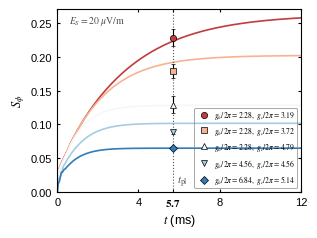

Figure saved as 'S_phi_Figure_20260914.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.


In [5]:
import warnings
import logging
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
from qutip import *
from google.colab import files

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Note: No unzip needed since S_phi_Data.npz is directly uploaded to Fig4_data
# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'Liberation Sans'],
    'mathtext.fontset': 'stix',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
})

# ================== 3. Physics Parameters & Data ==================
N_dim = 40
eta = 0.114
eps = 1e-10

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40 * 1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar / (2 * m * omega_trap))

phi_d = 0.0
t_list = np.linspace(0, 12e-3, 240)
t_obs_ms = 5.7
t_obs_sec = t_obs_ms * 1e-3
E_target = 20.0e-6      # Ideal theory line uses 20 uV/m

param_sets = [
    {"label": r"$\Omega_r/2\pi = 28.0$ kHz",  "Omega_r": 2*np.pi*28e3,   "Omega_b": 2*np.pi*20e3, "color": "#2E86AB", "lw": 1.5, "marker": 'o', "E_fit": 20.48e-6, "E_err_avg": 1.16e-6},
    {"label": r"$\Omega_r/2\pi = 32.6$ kHz",  "Omega_r": 2*np.pi*32.6e3, "Omega_b": 2*np.pi*20e3, "color": "#F18F01", "lw": 1.5, "marker": 's', "E_fit": 18.66e-6, "E_err_avg": 1.15e-6},
    {"label": r"$\Omega_r/2\pi = 40.0$ kHz",  "Omega_r": 2*np.pi*40e3,   "Omega_b": 2*np.pi*40e3, "color": "#2ECC71", "lw": 1.5, "marker": 'D', "E_fit": 17.56e-6, "E_err_avg": 0.53e-6},
    {"label": r"$\Omega_r/2\pi = 42.0$ kHz",  "Omega_r": 2*np.pi*42e3,   "Omega_b": 2*np.pi*20e3, "color": "#A23B72", "lw": 1.5, "marker": '^', "E_fit": 20.20e-6, "E_err_avg": 1.96e-6},
    {"label": r"$\Omega_r/2\pi = 45.1$ kHz",  "Omega_r": 2*np.pi*45.1e3, "Omega_b": 2*np.pi*60e3, "color": "#4A90E2", "lw": 1.5, "marker": 'v', "E_fit": 20.00e-6, "E_err_avg": 0.50e-6}
]

# ================== 4. Compute or Load Data ==================
npz_filename = 'S_phi_Data.npz'
save_data = {}

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation...")

    a = destroy(N_dim)
    I_m, I_i = qeye(N_dim), qeye(3)
    g, er, eb = basis(3,0), basis(3,1), basis(3,2)

    sig_rg_tot = tensor(er*g.dag(), I_m)
    sig_gr_tot = tensor(g*er.dag(), I_m)
    sig_bg_tot = tensor(eb*g.dag(), I_m)
    sig_gb_tot = tensor(g*eb.dag(), I_m)
    a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())
    n_op = tensor(I_i, num(N_dim))

    rho0 = tensor(g*g.dag(), basis(N_dim,0)*basis(N_dim,0).dag())
    opts = {'nsteps': 40000, 'atol': 1e-8, 'rtol': 1e-6}
    c_ops = [np.sqrt(150e3) * sig_gr_tot, np.sqrt(15e3) * sig_gb_tot]

    def compute_S_phi_at_t(E_val, t_target, H0_matrix):
        H_drive = tensor(I_i, -(E_val*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_d) - a.dag()*np.exp(-1j*phi_d)))
        sol = mesolve(H0_matrix + H_drive, rho0, [0, t_target], c_ops, e_ops=[n_op, a_tot], options=opts)
        n_val = sol.expect[0][-1]
        a_val = sol.expect[1][-1]
        return np.abs(a_val) / np.sqrt(n_val + eps)

    save_data = {
        't_list_ms': t_list * 1e3, 't_obs_ms': t_obs_ms, 'E_target_uVm': E_target * 1e6,
        'theory_curves': [], 'exp_points': [], 'param_labels': [], 'colors': [], 'markers': [],
        'Omega_r': [], 'Omega_b': [], 'E_fit_uVm': [], 'E_err_uVm': []
    }
    table_data = []

    for p in param_sets:
        H0 = (0.5 * 1j * p["Omega_r"] * eta * (sig_gr_tot * adag_tot - sig_rg_tot * a_tot) +
              0.5 * 1j * p["Omega_b"] * eta * (sig_bg_tot * adag_tot - sig_gb_tot * a_tot))

        H_drive_theory = tensor(I_i, -(E_target*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_d) - a.dag()*np.exp(-1j*phi_d)))
        res = mesolve(H0 + H_drive_theory, rho0, t_list, c_ops, e_ops=[n_op, a_tot], options=opts)
        S_t = np.abs(np.array(res.expect[1])) / np.sqrt(np.array(res.expect[0]) + eps)

        S_theory = S_t[np.argmin(np.abs(t_list - t_obs_sec))]
        S_center = compute_S_phi_at_t(p["E_fit"], t_obs_sec, H0)

        dE = 1e-7
        S_plus = compute_S_phi_at_t(p["E_fit"] + dE, t_obs_sec, H0)
        S_minus = compute_S_phi_at_t(p["E_fit"] - dE, t_obs_sec, H0)
        dS_dE = (S_plus - S_minus) / (2 * dE)
        S_phi_err_robust = np.abs(dS_dE) * p["E_err_avg"]

        dev_percent = (S_center - S_theory) / S_theory * 100
        table_data.append((p["label"], p["E_fit"]*1e6, p["E_err_avg"]*1e6, S_theory, S_center, S_phi_err_robust, dev_percent))

        save_data['theory_curves'].append({'t_ms': t_list * 1e3, 'S_phi': S_t})
        save_data['exp_points'].append({'t_ms': t_obs_ms, 'S': S_center, 'S_err': S_phi_err_robust})
        save_data['param_labels'].append(p["label"])
        save_data['colors'].append(p["color"])
        save_data['markers'].append(p["marker"])
        save_data['Omega_r'].append(p["Omega_r"])
        save_data['Omega_b'].append(p["Omega_b"])
        save_data['E_fit_uVm'].append(p["E_fit"] * 1e6)
        save_data['E_err_uVm'].append(p["E_err_avg"] * 1e6)

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")
    print("\n" + "="*125)
    print(f"Summary Table (Section t_pl = {t_obs_ms} ms)")
    print("-"*125)
    for item in table_data:
        lbl, e_f, e_e, s_th, s_cnt, s_err, dev = item
        print(f"{lbl:<28} | {e_f:.2f} ± {e_e:.2f} uV/m | Th: {s_th:.4f} | Exp: {s_cnt:.4f} ± {s_err:.4f} | Dev: {dev:>+7.2f}%")
    print("="*125)

else:
    print(f"Loading pre-computed data from GitHub repository...")
    # === MODIFIED: Point to Fig4_data instead of Fig3_data ===
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig4_data/{npz_filename}'
    if not os.path.exists(npz_path):
        npz_path = npz_filename # Fallback to current directory

    if os.path.exists(npz_path):
        loaded = np.load(npz_path, allow_pickle=True)
        save_data['t_list_ms'] = loaded['t_list_ms']
        save_data['t_obs_ms'] = loaded['t_obs_ms']
        save_data['E_target_uVm'] = loaded['E_target_uVm']
        save_data['theory_curves'] = loaded['theory_curves'].tolist()
        save_data['exp_points'] = loaded['exp_points'].tolist()
        save_data['param_labels'] = loaded['param_labels'].tolist()
        save_data['colors'] = loaded['colors'].tolist()
        save_data['markers'] = loaded['markers'].tolist()
        save_data['Omega_r'] = loaded['Omega_r'].tolist()
        save_data['Omega_b'] = loaded['Omega_b'].tolist()
        save_data['E_fit_uVm'] = loaded['E_fit_uVm'].tolist()
        save_data['E_err_uVm'] = loaded['E_err_uVm'].tolist()
        print("Data loaded successfully.")
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 5. Plotting (Beautiful Style) ==================
print("Generating Figure...")

t_list_ms = save_data['t_list_ms']
t_obs_ms = save_data['t_obs_ms']
theory_curves = save_data['theory_curves']
exp_points = save_data['exp_points']

# Manual legend configuration
config = [
    (0, r"$g_h/2\pi = 2.28,\ g_c/2\pi = 3.19$", 'o'),   # Circle
    (1, r"$g_h/2\pi = 2.28,\ g_c/2\pi = 3.72$", 's'),   # Square
    (3, r"$g_h/2\pi = 2.28,\ g_c/2\pi = 4.79$", '^'),   # Up Triangle
    (2, r"$g_h/2\pi = 4.56,\ g_c/2\pi = 4.56$", 'v'),   # Down Triangle
    (4, r"$g_h/2\pi = 6.84,\ g_c/2\pi = 5.14$", 'D'),   # Diamond
]

indices = [item[0] for item in config]
param_labels = [item[1] for item in config]
markers = [item[2] for item in config]

# Color palette: RdBu (forward) to match the desired style (red for small gc, blue for large gc)
cmap = plt.get_cmap('RdBu')
# Adjust the range to get a deep red at the start and deep blue at the end
positions = np.linspace(0.15, 0.85, len(config))
colors = [cmap(pos) for pos in positions]

fig, ax = plt.subplots(figsize=(3.0, 2.5))
ax.set_box_aspect(0.75)

# Plot theory curves
for idx, (data_idx, _, _) in enumerate(config):
    curve_dict = theory_curves[data_idx]
    ax.plot(curve_dict['t_ms'], curve_dict['S_phi'], color=colors[idx], lw=1.2, linestyle='-')

# Plot experimental points with error bars
for idx, (data_idx, _, marker) in enumerate(config):
    exp_dict = exp_points[data_idx]
    ax.errorbar(exp_dict['t_ms'], exp_dict['S'], yerr=exp_dict['S_err'], fmt=marker, color=colors[idx],
                ecolor='k', # <--- Force error bars to be black
                markersize=4.5, elinewidth=0.8, capsize=1.5, capthick=0.8,
                markeredgecolor='k', markeredgewidth=0.5, zorder=5)

# Vertical dashed line at 5.7 ms
ax.axvline(x=t_obs_ms, color='#555555', ls=':', lw=0.8, zorder=2)

# Axis labels and ticks
ax.set_xlabel(r"$t$ (ms)", fontsize=9, labelpad=3)
ax.set_ylabel(r"$S_{\phi}$", fontsize=9, labelpad=3)
ax.set_xlim(0, 12)
ax.set_ylim(bottom=0)

ticks = [0, 4, 8, 12, t_obs_ms]
tick_labels = ['0', '4', '8', '12', r'$\mathbf{5.7}$']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=8)

ax.text(t_obs_ms + 0.2, ax.get_ylim()[1] * 0.1, r'$t_{\mathrm{pl}}$', ha='left', va='top', fontsize=8, color='#555555')
ax.tick_params(axis='both', which='major', labelsize=8, length=2.5, width=0.8)

# Annotation for E_S = 20 uV/m
ax.text(0.05, 0.97, r'$E_S = 20\ \mu\mathrm{V/m}$', transform=ax.transAxes, fontsize=7, color='black', ha='left', va='top', alpha=0.7)

# Legend
handles = []
for i in range(len(config)):
    h = ax.plot([], [], color=colors[i], marker=markers[i], linestyle='None', markersize=4.5,
                markeredgecolor='k', markeredgewidth=0.5)[0]
    handles.append(h)

leg = ax.legend(handles, param_labels, loc='lower right', fontsize=5.5, frameon=True, fancybox=True,
                facecolor='none', edgecolor='gray', labelspacing=0.5, handletextpad=0.4, borderpad=0.2)
leg.get_frame().set_linewidth(0.6)

plt.tight_layout(pad=0.1)

# ================== 6. Save and Download ==================
run_date = datetime.now().strftime("%Y%m%d")
pdf_name = f"S_phi_Figure_{run_date}.pdf"
plt.savefig(pdf_name, dpi=600, bbox_inches='tight', transparent=True)
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 135 (delta 52), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 3.55 MiB | 14.54 MiB/s, done.
Resolving deltas: 100% (52/52), done.
Loading pre-computed data from GitHub repository...
Data loaded successfully.

Liouvillian gap and relaxation time for each workpoint (sorted descending by gap):
-------------------------------------------------------------------------------------
#    Workpoint (gc / gh)       Gap (s^-1)      Tau (ms)       
-------------------------------------------------------------------------------------
1    5.14 / 6.84 kHz           1688.4774       0.5922         
2    4.56 / 4.56 kHz           1341.0934       0.7457         
3    4.79 / 2.28 kHz           1141.7896       0.8758         
4    3.72 / 2.28 kHz           519.1148        1.

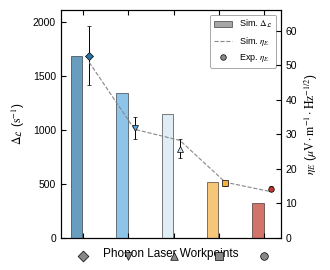

Figure saved as Liouvillian_Gap_Subplot_20260914.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.


In [11]:
import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from datetime import datetime
from tqdm import tqdm
import os
from matplotlib.ticker import MaxNLocator
from google.colab import files

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file from GitHub
# and instantly reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full Liouvillian gap calculation from
# scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Fix font warnings
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Physics Parameters ==================
N = 25
eta = 0.114

raw_param_sets = [
    {"label": "3.19 / 2.28 kHz", "Omega_r": 2*np.pi*28e3, "Omega_b": 2*np.pi*20e3,
     "gammar": 150e3, "gammab": 15e3, "color": "#2E86AB", "marker": 'o',
     "th_sens": 13.33, "exp_sens": 14.15, "exp_err": 0.77},
    {"label": "3.72 / 2.28 kHz", "Omega_r": 2*np.pi*32.6e3, "Omega_b": 2*np.pi*20e3,
     "gammar": 150e3, "gammab": 15e3, "color": "#F18F01", "marker": 's',
     "th_sens": 16.05, "exp_sens": 15.74, "exp_err": 0.78},
    {"label": "4.79 / 2.28 kHz", "Omega_r": 2*np.pi*42e3, "Omega_b": 2*np.pi*20e3,
     "gammar": 150e3, "gammab": 15e3, "color": "#A23B72", "marker": '^',
     "th_sens": 28.18, "exp_sens": 25.71, "exp_err": 2.77},
    {"label": "5.14 / 6.84 kHz", "Omega_r": 2*np.pi*45.1e3, "Omega_b": 2*np.pi*60e3,
     "gammar": 150e3, "gammab": 15e3, "color": "#4A90E2", "marker": 'v',
     "th_sens": 50.83, "exp_sens": 52.80, "exp_err": 8.65},
    {"label": "4.56 / 4.56 kHz", "Omega_r": 2*np.pi*40e3, "Omega_b": 2*np.pi*40e3,
     "gammar": 150e3, "gammab": 15e3, "color": "#2ECC71", "marker": 'D',
     "th_sens": 31.41, "exp_sens": 31.73, "exp_err": 3.15}
]

# ================== 3. Compute or Load Data ==================
npz_filename = 'Liouvillian_Gap_Data.npz'
data_loaded = False

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running rigorous Liouvillian gap calculation...")
    a = destroy(N)
    I_m, I_i = qeye(N), qeye(3)
    g, er, eb = basis(3,0), basis(3,1), basis(3,2)
    sig_rg_tot = tensor(er*g.dag(), I_m)
    sig_gr_tot = tensor(g*er.dag(), I_m)
    sig_bg_tot = tensor(eb*g.dag(), I_m)
    sig_gb_tot = tensor(g*eb.dag(), I_m)
    a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

    calculated_results = []
    print("="*60)
    print(f"Calculating Liouvillian Gaps (Truncation N={N})...")
    print("="*60)

    for p in tqdm(raw_param_sets, desc="Extracting Physical Gap", unit="config"):
        H0 = (0.5 * 1j * p["Omega_r"] * eta * (sig_gr_tot * adag_tot - sig_rg_tot * a_tot) +
              0.5 * 1j * p["Omega_b"] * eta * (sig_bg_tot * adag_tot - sig_gb_tot * a_tot))
        c_ops = [np.sqrt(p["gammar"]) * sig_gr_tot, np.sqrt(p["gammab"]) * sig_gb_tot]
        L = liouvillian(H0, c_ops)
        all_eigenvalues = L.eigenenergies()
        non_zero_decays = [abs(val.real) for val in all_eigenvalues if not np.isclose(val.real, 0.0, atol=1e-4)]
        true_gap = min(non_zero_decays) if non_zero_decays else 0.0
        res_dict = p.copy()
        res_dict["gap"] = true_gap
        calculated_results.append(res_dict)

    sorted_results = sorted(calculated_results, key=lambda x: x["gap"], reverse=True)
    labels = [item["label"] for item in sorted_results]
    gaps = [item["gap"] for item in sorted_results]
    th_sens = [item["th_sens"] for item in sorted_results]
    exp_sens = [item["exp_sens"] for item in sorted_results]
    exp_err = [item["exp_err"] for item in sorted_results]

    np.savez(npz_filename, labels=labels, gaps=gaps, th_sens=th_sens, exp_sens=exp_sens, exp_err=exp_err)
    print(f"\nData saved to {npz_filename}")
    data_loaded = True

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig4_data/{npz_filename}'
    if not os.path.exists(npz_path):
        npz_path = npz_filename
    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        gaps = data['gaps'].tolist()
        th_sens = data['th_sens'].tolist()
        exp_sens = data['exp_sens'].tolist()
        exp_err = data['exp_err'].tolist()
        print("Data loaded successfully.")
        data_loaded = True
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 3.5 Print gap and tau values ==================
if data_loaded:
    print("\n" + "="*85)
    print("Liouvillian gap and relaxation time for each workpoint (sorted descending by gap):")
    print("-"*85)
    print(f"{'#':<4} {'Workpoint (gc / gh)':<25} {'Gap (s^-1)':<15} {'Tau (ms)':<15}")
    print("-"*85)
    for i, (lbl, g) in enumerate(zip(labels, gaps)):
        tau_ms = 1000.0 / g if g > 0 else np.inf
        print(f"{i+1:<4} {lbl:<25} {g:<15.4f} {tau_ms:<15.4f}")
    print("="*85 + "\n")

# ================== 4. Plotting ==================
if data_loaded:
    print("Generating Figure...")
    marker_map = {
        "3.19 / 2.28 kHz": 'o',
        "3.72 / 2.28 kHz": 's',
        "4.79 / 2.28 kHz": '^',
        "5.14 / 6.84 kHz": 'D',
        "4.56 / 4.56 kHz": 'v'
    }
    markers = [marker_map.get(lbl, 'o') for lbl in labels]

    # Custom colors matching Fig 4a
    point_colors = {
        "3.19 / 2.28 kHz": "#C0392B", # Deep red
        "3.72 / 2.28 kHz": "#F5B041", # Peach/Orange
        "4.79 / 2.28 kHz": "#D4E6F1", # Very light blue
        "5.14 / 6.84 kHz": "#2874A6", # Deep blue
        "4.56 / 4.56 kHz": "#5DADE2"  # Light blue
    }
    bar_colors = [point_colors.get(lbl, '#888888') for lbl in labels]

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'Liberation Sans'],
        'mathtext.fontset': 'stix',
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
    })

    fig, ax1 = plt.subplots(figsize=(3.4, 2.8))
    x_indices = np.arange(len(labels))

    bars = ax1.bar(x_indices - 0.14, gaps, width=0.25, color=bar_colors, alpha=0.7,
                   edgecolor='black', linewidth=0.5)
    ax1.set_ylabel(r"$\Delta_{\mathcal{L}}$ ($\mathrm{s}^{-1}$)", fontsize=8.5)
    ax1.tick_params(axis='y', labelsize=7.5)
    ax1.set_ylim(0, max(gaps) * 1.25)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

    ax2 = ax1.twinx()
    ax2.tick_params(axis='y', labelsize=7.5)

    # === MODIFICATION: Marker color follows bar colors, error bars are black ===
    for i, m in enumerate(markers):
        ax2.errorbar(x_indices[i] + 0.14, exp_sens[i], yerr=exp_err[i],
                     fmt=m, color=bar_colors[i], ecolor='k', ms=4.0, elinewidth=0.7, capsize=1.2,
                     markeredgecolor='black', markeredgewidth=0.5)

    # Theory sensitivity line (keep gray)
    ax2.plot(x_indices + 0.14, th_sens, '--', color='#888888', lw=0.8)
    ax2.set_ylabel(r"$\eta_E$ ($\mu\mathrm{V}\cdot\mathrm{m}^{-1}\cdot\mathrm{Hz}^{-1/2}$)", fontsize=8.5)
    ax2.set_ylim(0, max(max(exp_sens), max(th_sens)) * 1.25)

    ax1.set_xticks(x_indices)
    ax1.set_xticklabels([])

    # x-axis markers: keep gray face
    for i, (x, m) in enumerate(zip(x_indices, markers)):
        y_axis_bottom = ax1.get_ylim()[0]
        y_offset = -0.08 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
        ax1.scatter(x, y_axis_bottom + y_offset, marker=m, s=30,
                    facecolor='#888888', edgecolor='black', linewidth=0.5,
                    zorder=10, clip_on=False)

    ax1.set_xlabel(r"Phonon Laser Workpoints", fontsize=8.5)

    bar_handle = plt.Rectangle((0,0), 1, 1, facecolor='gray', alpha=0.7, edgecolor='black', linewidth=0.5)
    theory_line = plt.Line2D([0], [0], color='#888888', linestyle='--', lw=0.8)
    exp_point = plt.Line2D([0], [0], marker='o', color='#888888', linestyle='None',
                           markersize=4, markeredgecolor='black', markeredgewidth=0.5)
    handles = [bar_handle, theory_line, exp_point]
    labels_legend = [r'Sim. $\Delta_{\mathcal{L}}$', r'Sim. $\eta_{E}$', r'Exp. $\eta_{E}$']
    leg = ax1.legend(handles, labels_legend, loc='upper right', fontsize=6.5,
                     frameon=True, fancybox=True, facecolor='none', edgecolor='gray')
    leg.get_frame().set_linewidth(0.6)

    plt.tight_layout()

    run_date = datetime.now().strftime("%Y%m%d")
    pdf_filename = f"Liouvillian_Gap_Subplot_{run_date}.pdf"
    plt.savefig(pdf_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved as {pdf_filename}")

    try:
        files.download(pdf_filename)
        print("PDF download triggered.")
        if RECOMPUTE_DATA:
            files.download(npz_filename)
            print("NPZ download triggered.")
    except Exception as e:
        print("Automatic download failed. Download manually from file browser.")
else:
    print("Data not loaded. Please check the configuration.")